In [1]:
import pickle
import os
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
import torch
from neuralhydrology.evaluation import metrics, eval_wrapper, comp_plots, ensemble_eval
from neuralhydrology.nh_run import start_run, eval_run

In [2]:
all_runs_dir = '/global/home/users/ann_scheliga/neuralhydrology/runs/'
exp_name ='EXP00'
default_order = ['SW_train','noSW_train','SW_test','noSW_test']

## Grouping runs

In [3]:
## Sort to EXP00
all_runs = os.listdir(all_runs_dir)
exp_runs = [run for run in all_runs if exp_name in run]
exp_runs.sort()

In [4]:
## Sort within EXP00
exp_count = eval_wrapper.check_exp_count(exp_runs)
exp_options = list(exp_count.keys())
exp_options.sort()
exp_options

EXP00_no_sw_NSE_10basin :	 8
EXP00_no_sw_MSE_10basin :	 8
EXP00_wi_sw_NSE_10basin :	 8
EXP00_wi_sw_MSE_10basin :	 8


['EXP00_no_sw_MSE_10basin',
 'EXP00_no_sw_NSE_10basin',
 'EXP00_wi_sw_MSE_10basin',
 'EXP00_wi_sw_NSE_10basin']

In [5]:
names_MSE_no_sw = [run for run in all_runs if 'EXP00_no_sw_MSE_10basin' in run]
names_MSE_wi_sw = [run for run in all_runs if 'EXP00_wi_sw_MSE_10basin' in run]

names_NSE_no_sw = [run for run in all_runs if 'EXP00_no_sw_NSE_10basin' in run]
names_NSE_wi_sw = [run for run in all_runs if 'EXP00_wi_sw_NSE_10basin' in run]

## Evaluate results

In [6]:
tuple_MSE = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_MSE_no_sw,wisw_exp_names = names_MSE_wi_sw,run_dir=all_runs_dir)
tuple_NSE = ensemble_eval.eval_sw_from_name_lists(nosw_exp_names = names_NSE_no_sw,wisw_exp_names = names_NSE_wi_sw,run_dir=all_runs_dir)

/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_3108_025322
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_3108_025322
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_3108_031804
Evaluation complete of /global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_3108_031804
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
dict_keys(['1159302', '1834101', '3103450', '4148535', '4150600', '4150680', '4150700', '4152450', '5101500', '5608096'])
/global/home/users/ann_scheliga/neuralhydrology/runs/EXP00_no_sw_MSE_10basin_3108_032259
Evaluation complete o

(0.0, 400.0)

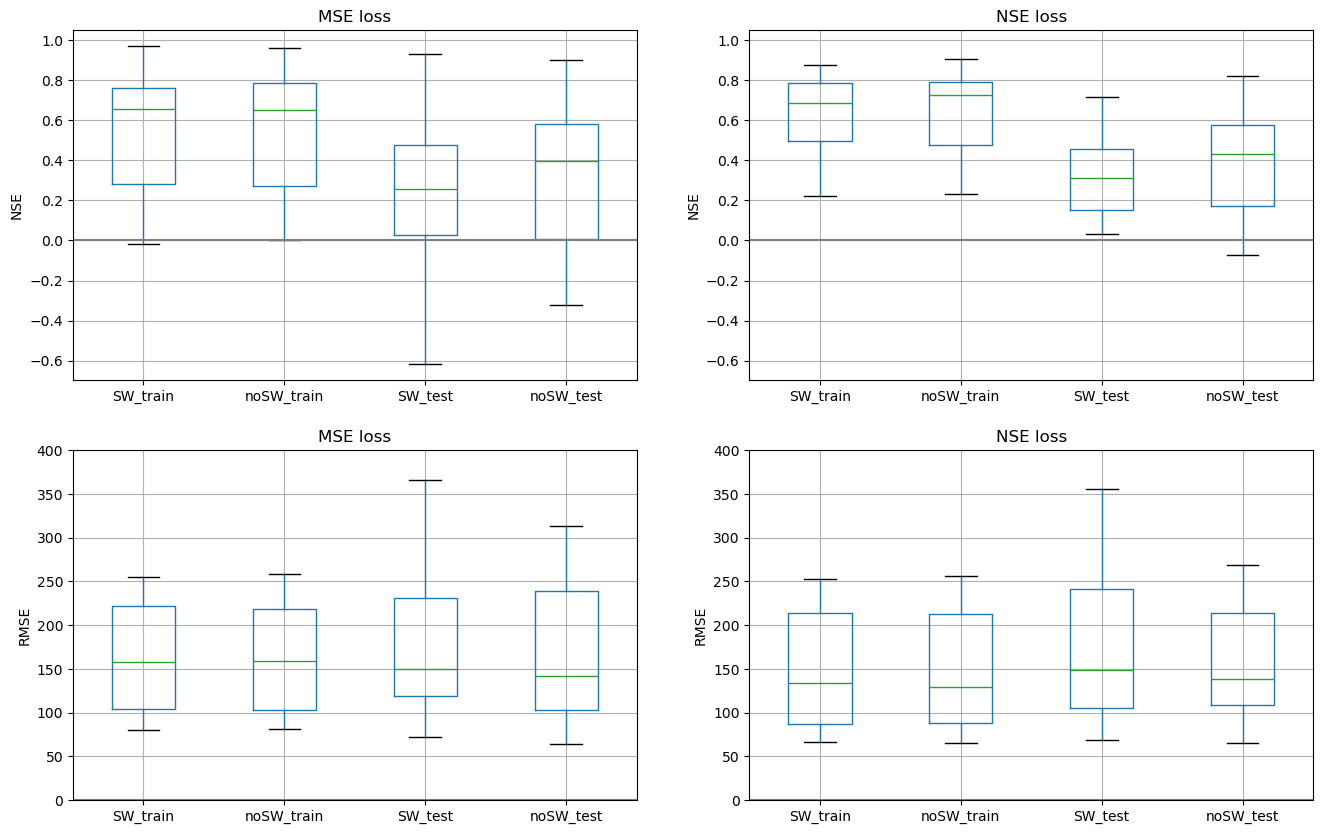

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))\

axs[0, 0].sharey(axs[0, 1])
axs[1, 0].sharey(axs[1, 1])

MSE_nse_df = comp_plots.boxplot_from_tuple(tuple_MSE,ax=axs[0,0],tuple_names=default_order,exp_name = 'MSE loss')
NSE_nse_df = comp_plots.boxplot_from_tuple(tuple_NSE,ax=axs[0,1],tuple_names=default_order,exp_name = 'NSE loss')

MSE_mse_df = comp_plots.boxplot_from_tuple(tuple_MSE,ax=axs[1,0],tuple_names=default_order,exp_name = 'MSE loss',metric_name="RMSE")
NSE_mse_df = comp_plots.boxplot_from_tuple(tuple_NSE,ax=axs[1,1],tuple_names=default_order,exp_name = 'NSE loss',metric_name="RMSE")
axs[1,0].set_ylim([0,400])

In [14]:
MSE_mse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,105.848529,1098.130400,255.246289,79.913017,212.381355,104.115940,225.578977,102.002642,181.008222,134.910474
noSW_train,96.354053,1245.279437,258.316711,81.106625,207.630550,107.945308,222.656107,101.042249,180.902949,137.736593
SW_test,236.236557,1396.961122,215.339539,89.361559,120.815907,72.059454,118.932766,123.403805,366.405023,175.464773
noSW_test,238.141847,1653.644914,239.594979,73.369693,118.171977,64.072095,98.347136,127.189262,313.358508,157.188072


In [15]:
NSE_mse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,74.390289,3707.095629,253.160206,66.362320,221.001874,86.563366,191.944521,89.250446,141.122696,126.891878
noSW_train,65.124936,2897.909591,256.263750,68.026211,214.756812,88.889105,206.201680,87.303515,133.150320,124.848228
SW_test,252.481698,2801.020171,208.646625,68.638336,114.199806,71.606745,123.558445,103.027487,356.133468,173.108737
noSW_test,195.044256,2225.495001,219.671079,65.609980,113.634140,70.524226,107.548581,111.642570,268.172505,163.523281


In [9]:
MSE_nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,0.749287,0.970374,0.236076,0.195633,0.762598,0.713410,0.597284,-0.016941,0.428281,0.811098
noSW_train,0.792246,0.961903,0.217585,0.171426,0.773100,0.691941,0.607653,0.002120,0.428945,0.803101
SW_test,0.541665,0.929951,-0.031635,-0.617532,0.274246,0.487368,0.443818,-0.244771,0.234720,0.199282
noSW_test,0.534242,0.901844,-0.277128,-0.090398,0.305663,0.594714,0.619691,-0.322309,0.440267,0.357403


In [10]:
NSE_nse_df

,1159302,1834101,3103450,4148535,4150600,4150680,4150700,4152450,5101500,5608096
SW_train,0.876166,0.662379,0.248511,0.445295,0.742935,0.801895,0.708423,0.221440,0.652479,0.832886
noSW_train,0.905092,0.793684,0.229974,0.417130,0.757257,0.791107,0.663500,0.255035,0.690635,0.838226
SW_test,0.476461,0.718380,0.031497,0.045700,0.351557,0.493788,0.399713,0.132363,0.277026,0.220641
noSW_test,0.687568,0.822220,-0.073555,0.128051,0.357965,0.508978,0.545197,-0.018807,0.590055,0.304562


In [11]:
tuple_MSE[0]['1159302']['1D']

{'xr': <xarray.Dataset> Size: 96kB
 Dimensions:    (time_step: 1, date: 4018)
 Coordinates:
   * date       (date) datetime64[ns] 32kB 2010-01-01 2010-01-02 ... 2020-12-31
   * time_step  (time_step) int64 8B 0
 Data variables:
     Q_sim      (date, time_step) float32 16kB 123.8 116.6 94.12 ... 290.7 311.7
     Qsim_std   (date, time_step) float32 16kB 16.7 19.61 26.34 ... 102.6 115.1
     Q_obs      (date, time_step) float32 16kB 100.6 101.0 103.5 ... 186.2 198.1
     Qobs_std   (date, time_step) float32 16kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0,
 'NSE': 0.7492866029453494,
 'RMSE': 105.84852919531995}